# Unsupervised analysis

**ML-MDS 2026 - Elisa Müller and Berta Torrents**

## 0. Introduction

This notebook performs unsupervised analysis on the full preprocessed dataset, applied after preprocessing but before any supervised feature selection. Since the analysis is purely exploratory and cluster assignments are not used as inputs to any subsequent supervised model, there is no risk of data leakage in using the complete set of samples.

PCA is applied exclusively to the seven continuous features, as it assumes continuous inputs and would be distorted by the high proportion of one-hot encoded columns. The goal is to uncover the variance structure of the numerical variables, identify redundant or correlated features, and assess whether the directions of maximum variance align with income as a supplementary variable.

K-Means and GMM clustering are also applied to the continuous features for the same reasons. Cluster assignments are then profiled against the full feature set, including categorical variables and the income label, to assess whether the discovered structure maps onto meaningful socioeconomic groups. As a complementary extension, K-Prototypes incorporates categorical variables directly into the clustering to validate whether the structure found on continuous features alone is robust to the inclusion of nominal information.

## 1. Setup and data loading

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

RANDOM_STATE = 42

PLOT_COLORS = {
    "neutral": "#00B4D8",
    "neutral_light": "#7DB7FF",
    "income_low": "#2F80ED",
    "income_high": "#FF8A00",
    "after": "#00B894",
    "outlier": "#E63946",
    "mild": "#F2C94C",
    "severe": "#E63946",
    "reference": "#4A5568",
}
TARGET_PALETTE_NUMERIC = {0: PLOT_COLORS["income_low"], 1: PLOT_COLORS["income_high"]}

sns.set_theme(
    style="whitegrid",
    palette=[PLOT_COLORS["neutral"], PLOT_COLORS["income_high"], PLOT_COLORS["after"], PLOT_COLORS["outlier"]],
    rc={
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.edgecolor": "#D7DEE8",
        "axes.linewidth": 0.8,
        "grid.color": "#E8EDF3",
        "grid.linewidth": 0.7,
        "legend.frameon": False,
    },
)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.titlepad"] = 10


def polish_axes(ax, grid_axis="y"):
    ax.grid(False)
    ax.grid(True, axis=grid_axis, alpha=0.55)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
    return ax

In [2]:
PROCESSED_FILES = {
    "X_train": "adult_X_train.csv",
    "X_test": "adult_X_test.csv",
    "y_train": "adult_y_train.csv",
    "y_test": "adult_y_test.csv",
    "preprocessor": "preprocessor.joblib",
}

missing_files = [name for name, path in PROCESSED_FILES.items() if not Path(path).exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing processed file(s): "
        + ", ".join(missing_files)
        + ". Run preprocessing_adult_census.ipynb first."
    )

X_train = pd.read_csv(PROCESSED_FILES["X_train"], index_col=0)
X_test = pd.read_csv(PROCESSED_FILES["X_test"], index_col=0)
y_train = pd.read_csv(PROCESSED_FILES["y_train"], index_col=0).squeeze("columns")
y_test = pd.read_csv(PROCESSED_FILES["y_test"], index_col=0).squeeze("columns")
preprocessor = joblib.load(PROCESSED_FILES["preprocessor"])

X = pd.concat([X_train, X_test]).sort_index()
y = pd.concat([y_train, y_test]).sort_index()

analysis_df = X.copy()
analysis_df["income"] = y.loc[analysis_df.index]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
display(analysis_df.head())

X shape: (32561, 73)
y shape: (32561,)


,num__age,num__education_num,num__hours_per_week,num__capital_gain_log,num__capital_loss_log,num__net_capital,num__age_x_hours,bin__sex,bin__capital_gain_is_99999,bin__has_capital_activity,...,cat__relationship_Wife,cat__race_Amer-Indian-Eskimo,cat__race_Asian-Pac-Islander,cat__race_Black,cat__race_Other,cat__race_White,cat__capital_direction_gain,cat__capital_direction_loss,cat__capital_direction_none,income
0,3.776660,-0.419226,-0.03412,-0.300842,5.031931,-1.797389,2.754749,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
1,3.189651,-0.419226,-1.81908,-0.300842,5.031931,-1.797389,-0.125426,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
2,2.015634,-0.031235,-0.03412,-0.300842,5.031931,-1.797389,1.452975,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0
3,1.135121,-2.359179,-0.03412,-0.300842,4.962607,-1.630647,0.802088,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
4,0.181232,-0.031235,-0.03412,-0.300842,4.962607,-1.630647,0.096961,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0


## 2. Principal Component Analysis

PCA is applied to the seven continuous features only. This gives a theoretically clean decomposition, since PCA assumes continuous inputs and its geometry would be distorted by the high proportion of binary one-hot columns. The income label is used exclusively as a supplementary coloring variable on the score plots and does not influence the components in any way.

### 2.1 Variance decomposition

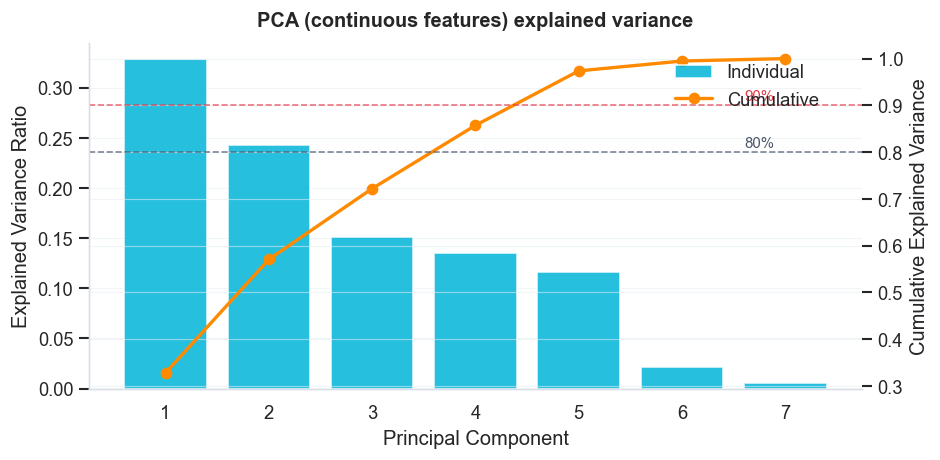

Components needed for 80% variance: 4
Components needed for 90% variance: 5


In [3]:
CONTINUOUS_COLS = [
    "num__age",
    "num__education_num",
    "num__hours_per_week",
    "num__capital_gain_log",
    "num__capital_loss_log",
    "num__net_capital",
    "num__age_x_hours",
]

X_cont = X[CONTINUOUS_COLS].values

pca_cont = PCA(random_state=RANDOM_STATE)
pca_cont.fit(X_cont)
X_cont_pca = pca_cont.transform(X_cont)

explained_cont = pca_cont.explained_variance_ratio_
cumulative_cont = np.cumsum(explained_cont)
n_cont = len(CONTINUOUS_COLS)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(range(1, n_cont + 1), explained_cont, color=PLOT_COLORS["neutral"], alpha=0.85, label="Individual")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")

ax2 = ax1.twinx()
ax2.plot(range(1, n_cont + 1), cumulative_cont, color=PLOT_COLORS["income_high"], marker="o", linewidth=2, label="Cumulative")
ax2.set_ylabel("Cumulative Explained Variance")
ax2.axhline(0.80, color=PLOT_COLORS["reference"], linestyle="--", linewidth=1.0, alpha=0.7)
ax2.axhline(0.90, color=PLOT_COLORS["severe"], linestyle="--", linewidth=1.0, alpha=0.7)
ax2.text(n_cont - 0.4, 0.81, "80%", color=PLOT_COLORS["reference"], fontsize=9)
ax2.text(n_cont - 0.4, 0.91, "90%", color=PLOT_COLORS["severe"], fontsize=9)

polish_axes(ax1)
polish_axes(ax2)
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.title("PCA (continuous features) explained variance")
plt.tight_layout()
plt.show()

for threshold in [0.80, 0.90]:
    n = np.argmax(cumulative_cont >= threshold) + 1
    print(f"Components needed for {int(threshold*100)}% variance: {n}")

The variance is notably spread across all seven components with no single dominant axis. PC1 explains approximately 33% and PC2 approximately 25%, and four components are needed to reach 80%. This distribution suggests the continuous features carry largely independent information. The loadings analysis below identifies which features drive each component and explains why variance is distributed so broadly.

### 2.2 Loadings

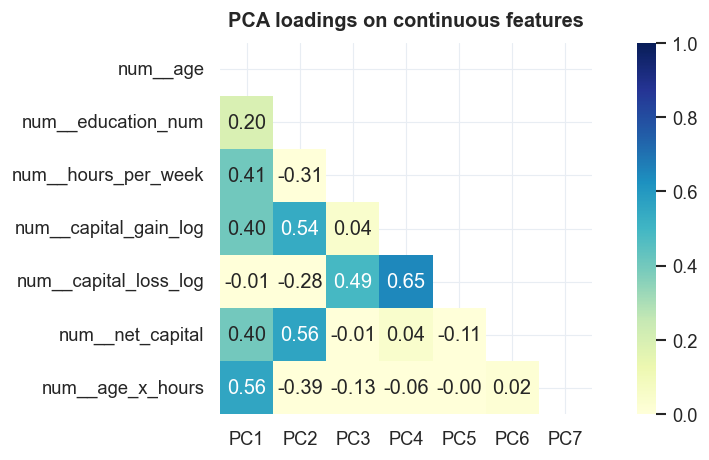

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
num__age,0.405,-0.261,-0.414,0.478,0.361,-0.014,-0.488
num__education_num,0.195,0.037,0.722,-0.014,0.662,-0.031,0.006
num__hours_per_week,0.406,-0.311,0.218,-0.568,-0.350,-0.021,-0.496
num__capital_gain_log,0.403,0.537,0.043,0.158,-0.225,-0.687,0.018
num__capital_loss_log,-0.006,-0.283,0.490,0.647,-0.498,0.116,-0.006
num__net_capital,0.401,0.559,-0.005,0.040,-0.109,0.716,-0.024
num__age_x_hours,0.557,-0.390,-0.133,-0.064,-0.004,0.019,0.718


In [4]:
loadings = pd.DataFrame(
    pca_cont.components_.T,
    index=CONTINUOUS_COLS,
    columns=[f"PC{i+1}" for i in range(n_cont)]
)

fig, ax = plt.subplots(figsize=(8, 4))
mask = np.triu(np.ones_like(loadings, dtype=bool))
sns.heatmap(loadings, mask=mask, annot=True, fmt=".2f",
            cmap="YlGnBu", vmin=0, vmax=1, ax=ax, square=True)
ax.set_title("PCA loadings on continuous features")
plt.tight_layout()
plt.show()

display(loadings.round(3))

PC1 loads positively and fairly evenly on `age`, `hours_per_week`, `capital_gain_log`, `net_capital`, and most strongly on `age_x_hours` (0.56). This component captures a general socioeconomic activity dimension where older individuals who work longer hours and have capital activity score high. The `age_x_hours` interaction term dominates this axis as expected, since it was engineered precisely to capture this combined effect.

PC2 is driven by `capital_gain_log` (0.54) and `net_capital` (0.56), with a negative contribution from `age_x_hours` (0.39 in the opposite direction). This axis captures capital activity independent of work effort and separates passive income from labor income.

PC3 and PC4 are dominated by `education_num` (0.72) and `capital_loss_log` (0.65) respectively, confirming that education level and capital loss carry largely orthogonal information relative to the first two components. This orthogonality explains why variance is so broadly distributed. The spread across components reflects the dataset's genuine multidimensionality rather than noise. Age, education, work hours, and capital activity are socioeconomically distinct dimensions that PCA cannot collapse into fewer axes without significant information loss.

### 2.3 Score plots colored by income

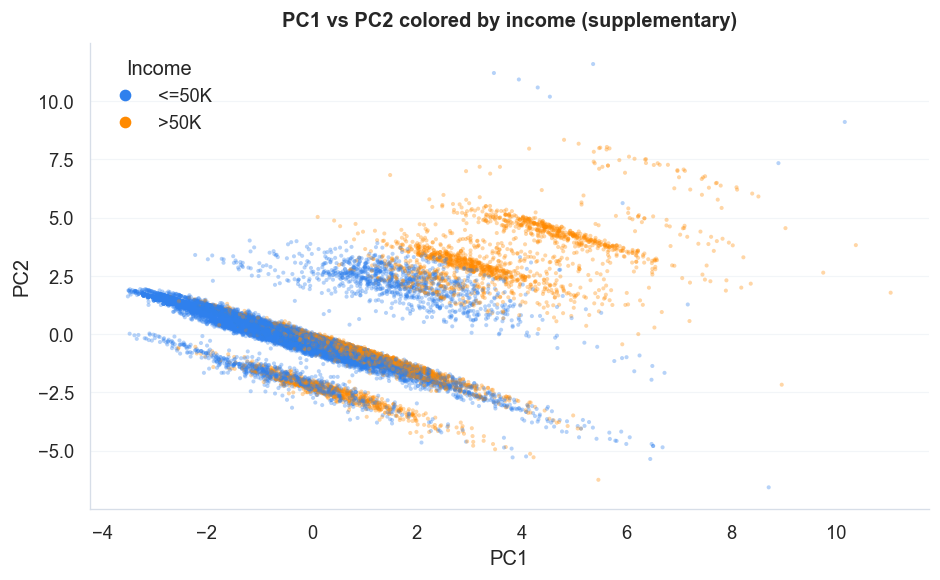

In [5]:
income_numeric = y.loc[X.index].values

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    X_cont_pca[:, 0], X_cont_pca[:, 1],
    c=[TARGET_PALETTE_NUMERIC[int(v)] for v in income_numeric], alpha=0.35, s=6, edgecolors="none"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PC1 vs PC2 colored by income (supplementary)")
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=label, markersize=6)
    for label, color in [("<=50K", TARGET_PALETTE_NUMERIC[0]), (">50K", TARGET_PALETTE_NUMERIC[1])]
]
ax.legend(handles=handles, title="Income")
polish_axes(ax)
plt.tight_layout()
plt.show()

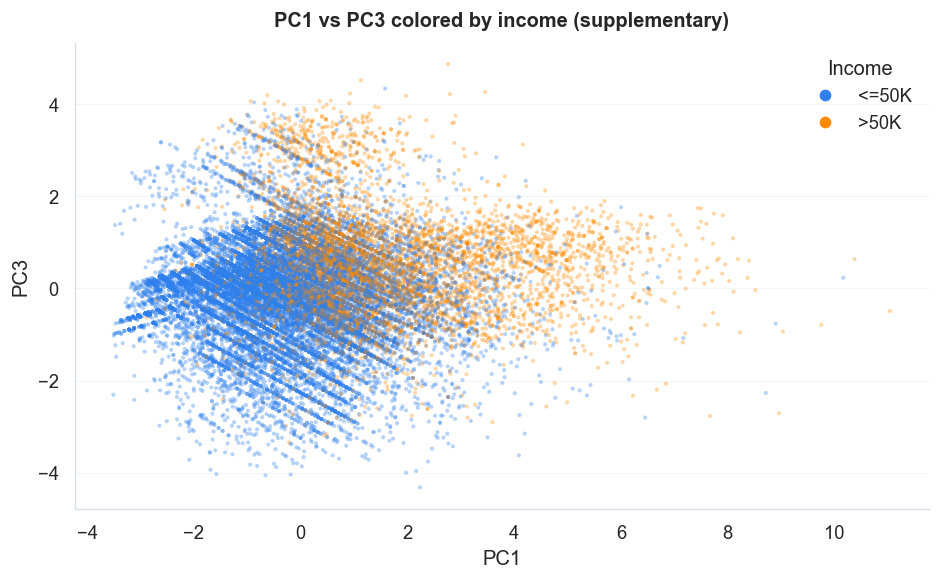

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    X_cont_pca[:, 0], X_cont_pca[:, 2],
    c=[TARGET_PALETTE_NUMERIC[int(v)] for v in income_numeric], alpha=0.35, s=6, edgecolors="none"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC3")
ax.set_title("PC1 vs PC3 colored by income (supplementary)")
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=label, markersize=6)
    for label, color in [("<=50K", TARGET_PALETTE_NUMERIC[0]), (">50K", TARGET_PALETTE_NUMERIC[1])]
]
ax.legend(handles=handles, title="Income")
polish_axes(ax)
plt.tight_layout()
plt.show()

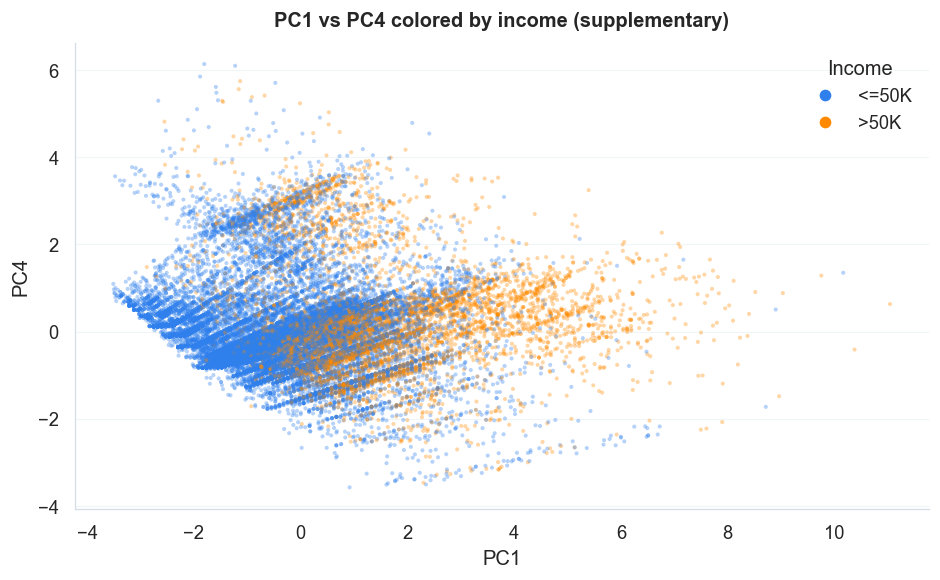

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    X_cont_pca[:, 0], X_cont_pca[:, 3],
    c=[TARGET_PALETTE_NUMERIC[int(v)] for v in income_numeric], alpha=0.35, s=6, edgecolors="none"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC4")
ax.set_title("PC1 vs PC4 colored by income (supplementary)")
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=label, markersize=6)
    for label, color in [("<=50K", TARGET_PALETTE_NUMERIC[0]), (">50K", TARGET_PALETTE_NUMERIC[1])]
]
ax.legend(handles=handles, title="Income")
polish_axes(ax)
plt.tight_layout()
plt.show()

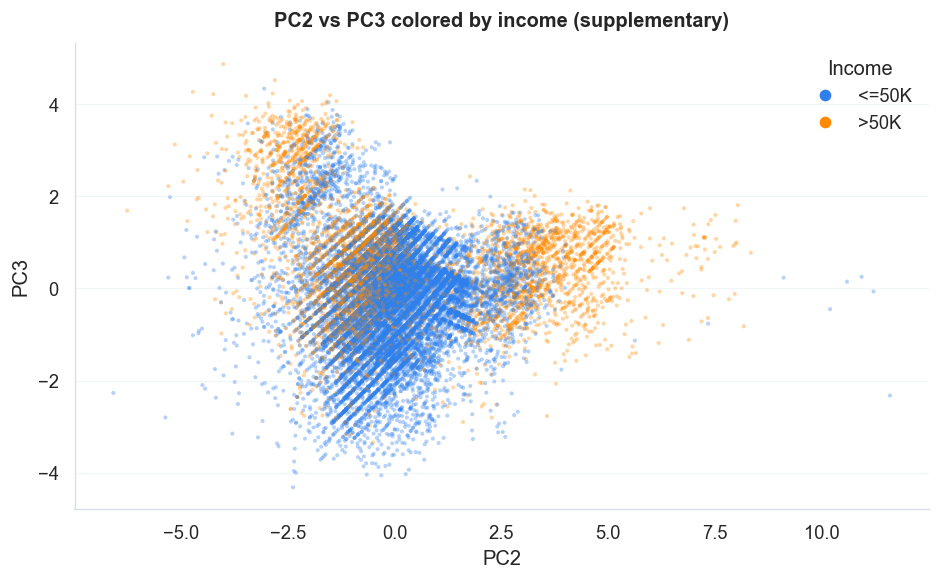

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    X_cont_pca[:, 1], X_cont_pca[:, 2],
    c=[TARGET_PALETTE_NUMERIC[int(v)] for v in income_numeric], alpha=0.35, s=6, edgecolors="none"
)
ax.set_xlabel("PC2")
ax.set_ylabel("PC3")
ax.set_title("PC2 vs PC3 colored by income (supplementary)")
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=label, markersize=6)
    for label, color in [("<=50K", TARGET_PALETTE_NUMERIC[0]), (">50K", TARGET_PALETTE_NUMERIC[1])]
]
ax.legend(handles=handles, title="Income")
polish_axes(ax)
plt.tight_layout()
plt.show()

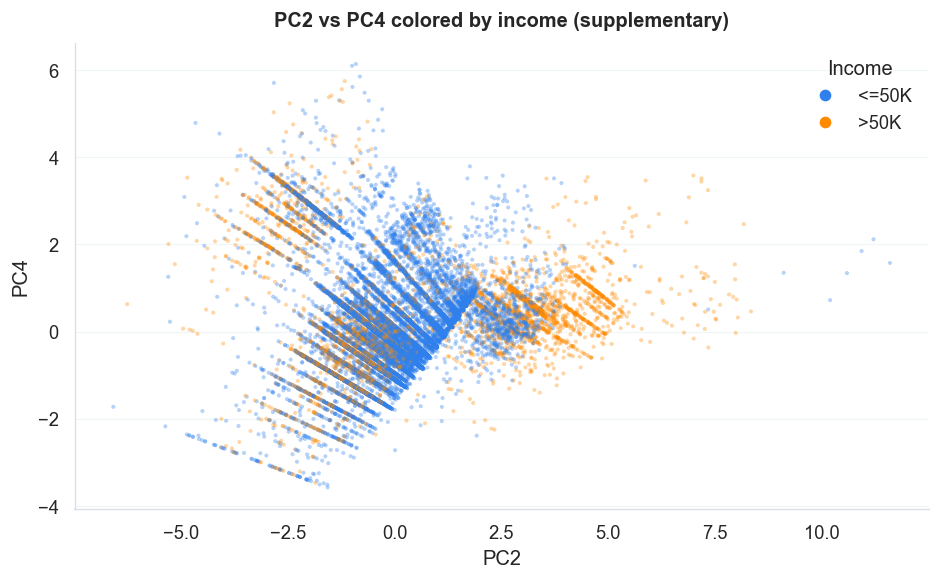

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    X_cont_pca[:, 1], X_cont_pca[:, 3],
    c=[TARGET_PALETTE_NUMERIC[int(v)] for v in income_numeric], alpha=0.35, s=6, edgecolors="none"
)
ax.set_xlabel("PC2")
ax.set_ylabel("PC4")
ax.set_title("PC2 vs PC4 colored by income (supplementary)")
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=label, markersize=6)
    for label, color in [("<=50K", TARGET_PALETTE_NUMERIC[0]), (">50K", TARGET_PALETTE_NUMERIC[1])]
]
ax.legend(handles=handles, title="Income")
polish_axes(ax)
plt.tight_layout()
plt.show()

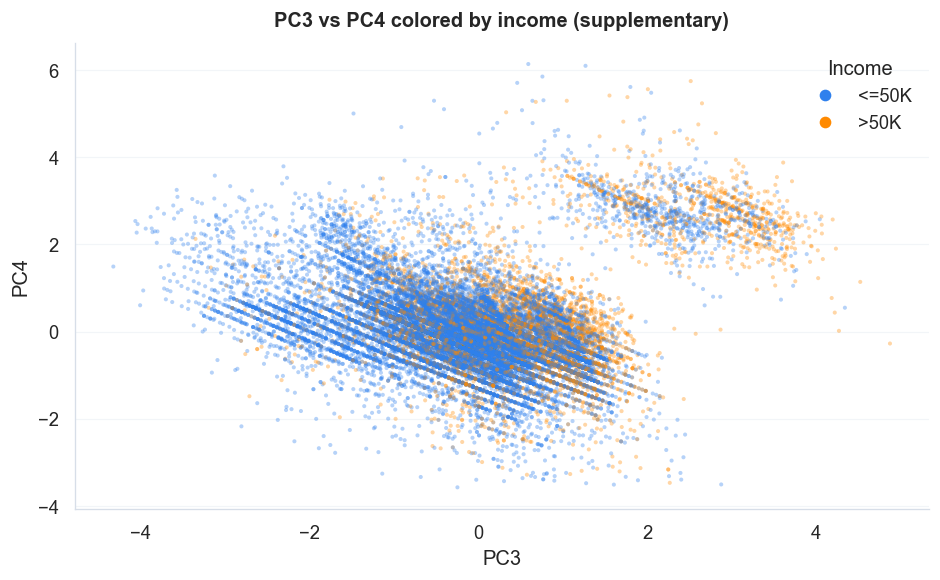

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    X_cont_pca[:, 2], X_cont_pca[:, 3],
    c=[TARGET_PALETTE_NUMERIC[int(v)] for v in income_numeric], alpha=0.35, s=6, edgecolors="none"
)
ax.set_xlabel("PC3")
ax.set_ylabel("PC4")
ax.set_title("PC3 vs PC4 colored by income (supplementary)")
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=label, markersize=6)
    for label, color in [("<=50K", TARGET_PALETTE_NUMERIC[0]), (">50K", TARGET_PALETTE_NUMERIC[1])]
]
ax.legend(handles=handles, title="Income")
polish_axes(ax)
plt.tight_layout()
plt.show()

PC1 shows the clearest gradient with income across all score plots. High PC1 values consistently correspond to the >50K class, confirming that the socioeconomic activity dimension is meaningfully aligned with income despite being constructed without the label.

The parallel stripe pattern visible in several plots reflects the discrete nature of features such as `education_num` and `hours_per_week`, which create natural bands in PCA space.

The PC3 vs PC4 plot shows the clearest visual separation between income groups, producing two largely distinct clouds. Although these components explain approximately 30% of variance combined, they capture education level and capital activity direction, which are among the strongest individual predictors of income. This illustrates a key limitation of PCA as an unsupervised method. The directions of maximum variance do not always coincide with the most discriminative directions.

## 3. K-Means clustering

K-Means is applied to the same seven continuous features used for PCA. Candidate values k = 2, 3, 4, 5, 6, 8, 10 are evaluated using the elbow method on inertia and the silhouette score. Cluster assignments for the selected k are then profiled against the full feature set to assess whether the discovered structure maps onto meaningful socioeconomic groups.

### 3.1 Cluster count selection

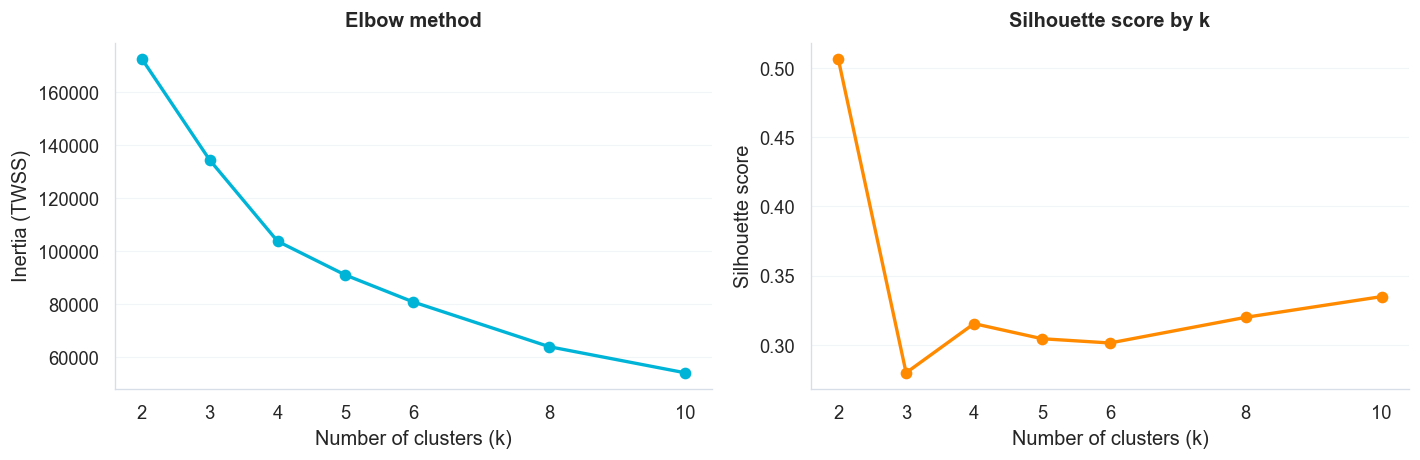

  k=2: 0.5066
  k=3: 0.2798
  k=4: 0.3153
  k=5: 0.3044
  k=6: 0.3013
  k=8: 0.3198
  k=10: 0.3348


In [11]:
K_VALUES = [2, 3, 4, 5, 6, 8, 10]

inertias = []
silhouettes = []

for k in K_VALUES:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
    labels = km.fit_predict(X_cont)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cont, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_VALUES, inertias, marker="o", color=PLOT_COLORS["neutral"], linewidth=2)
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia (TWSS)")
ax1.set_title("Elbow method")
ax1.set_xticks(K_VALUES)
polish_axes(ax1)

ax2.plot(K_VALUES, silhouettes, marker="o", color=PLOT_COLORS["income_high"], linewidth=2)
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette score by k")
ax2.set_xticks(K_VALUES)
polish_axes(ax2)

plt.tight_layout()
plt.show()

for k, s in zip(K_VALUES, silhouettes):
    print(f"  k={k}: {s:.4f}")

The elbow curve shows a gradual decrease in inertia with no sharp bend, suggesting the continuous features do not form strongly separated natural clusters. A slight inflection is visible around k=4. The silhouette score peaks at k=2 (0.507) but drops sharply at k=3 and remains flat around 0.30 to 0.33 for higher values, indicating that beyond k=2 the clusters become less compact relative to their separation.

The two criteria do not fully agree. k=2 produces the most statistically cohesive partition but is too coarse to yield meaningful socioeconomic groups, as it would likely reduce to a simple high vs. low capital activity split. k=4 is therefore selected, corresponding to the slight inflection in the inertia curve while offering a better silhouette than k=3 and sufficient granularity for interpretable profiling.

### 3.2 Cluster visualization and income profiling

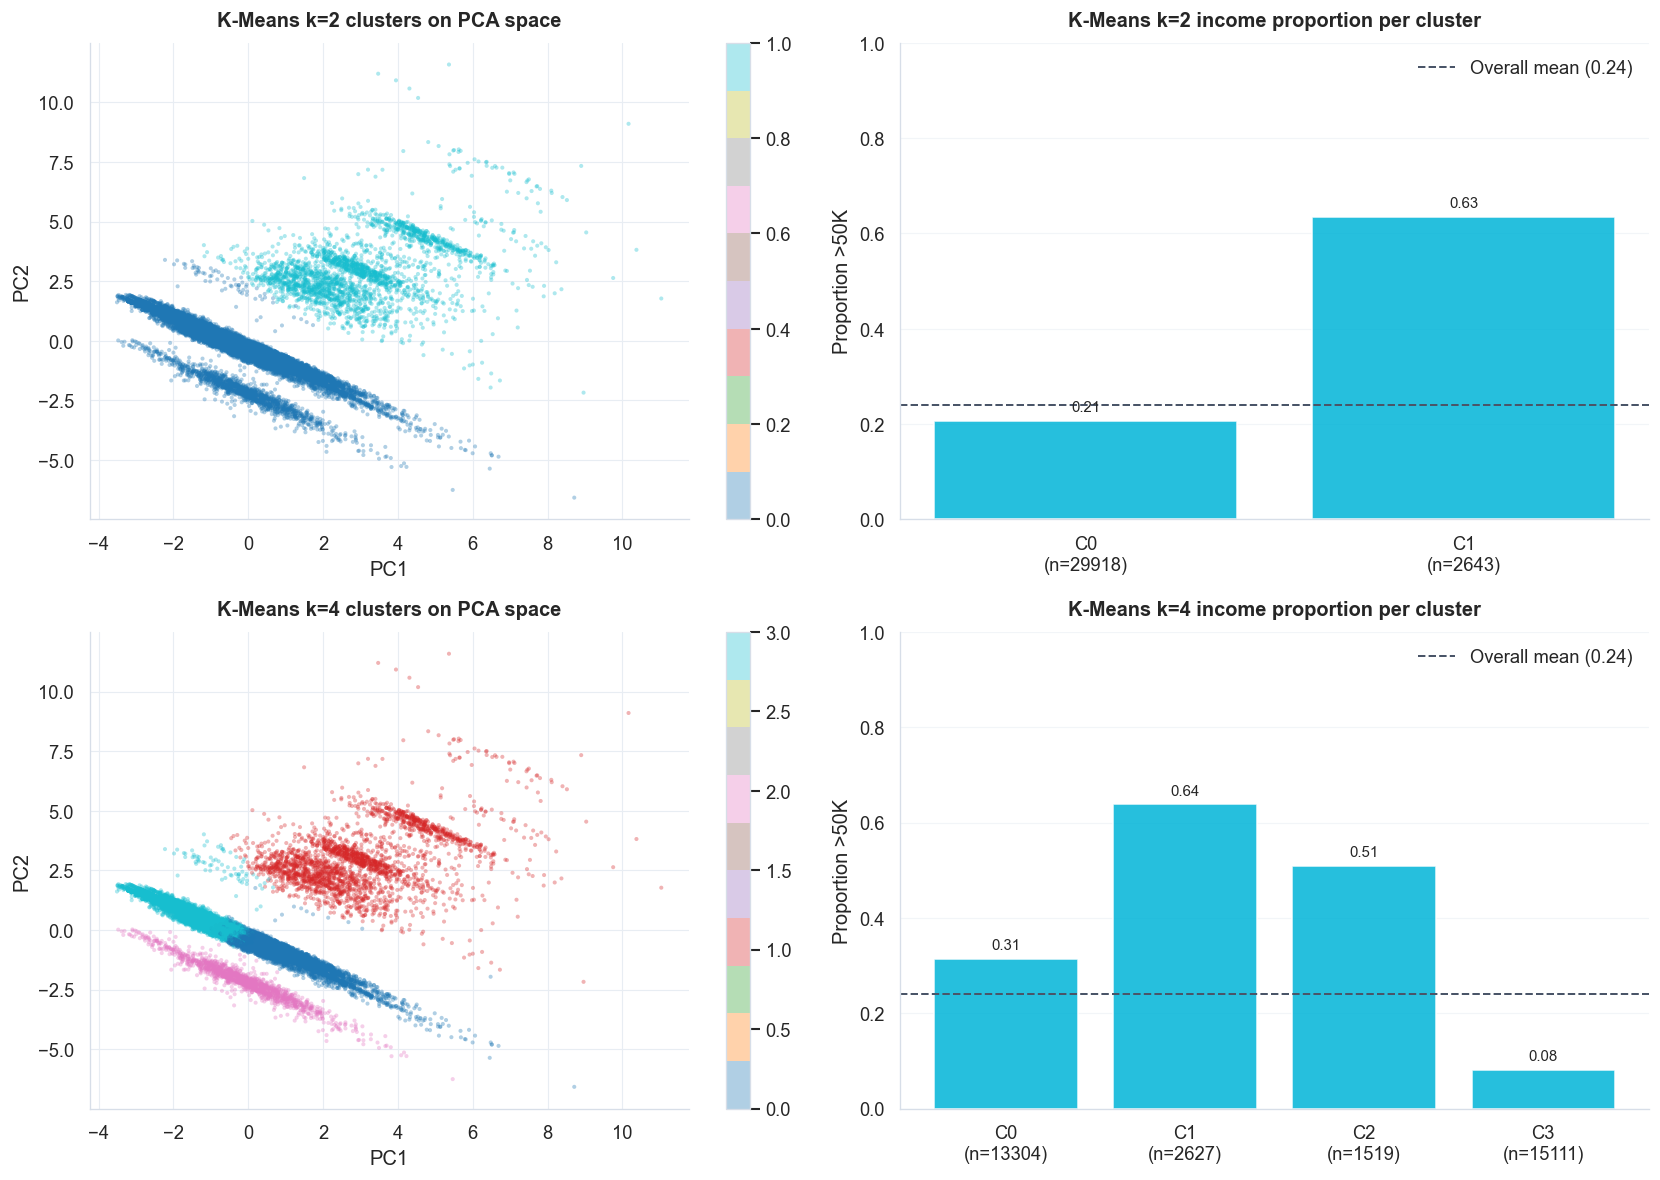

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, k in enumerate([2, 4]):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
    labels = km.fit_predict(X_cont)
    if k == 4:
        km_labels = labels

    ax = axes[idx, 0]
    scatter = ax.scatter(
        X_cont_pca[:, 0], X_cont_pca[:, 1],
        c=labels, cmap="tab10", alpha=0.35, s=6, edgecolors="none"
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"K-Means k={k} clusters on PCA space")
    plt.colorbar(scatter, ax=ax)

    ax = axes[idx, 1]
    cluster_df = X[CONTINUOUS_COLS].copy()
    cluster_df["cluster"] = labels
    cluster_df["income"] = y.loc[X.index].values
    income_prop = cluster_df.groupby("cluster")["income"].mean()
    cluster_size = cluster_df.groupby("cluster")["income"].count()

    bars = ax.bar(
        [f"C{c}\n(n={cluster_size[c]})" for c in income_prop.index],
        income_prop.values,
        color=PLOT_COLORS["neutral"], alpha=0.85
    )
    ax.axhline(y.mean(), color=PLOT_COLORS["reference"], linestyle="--", linewidth=1.2, label=f"Overall mean ({y.mean():.2f})")
    ax.set_ylabel("Proportion >50K")
    ax.set_title(f"K-Means k={k} income proportion per cluster")
    ax.set_ylim(0, 1)
    ax.legend()
    polish_axes(ax)

    for bar, val in zip(bars, income_prop.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

K-Means with k=2 isolates a very small group (n=2,643, approximately 8% of the data) with a high proportion of >50K earners (63%), while the remaining 92% fall into a single large cluster with only 21% >50K. The most natural binary split in the continuous feature space is therefore not a broad high vs. low income division but rather the separation of a small subgroup with significant capital activity from everyone else. This partition is informative but too coarse for meaningful socioeconomic profiling.

k=4 provides a much richer structure. The four clusters show a clear income gradient from C3 (8% >50K, n=15,111) through C0 (31%) and C2 (51%) to C1 (64%, n=2,627). The continuous features naturally stratify individuals into groups with meaningfully different income profiles even though income was not used to construct the clusters. The k=4 partition is used for all subsequent profiling.

### 3.3 Numeric profiling

In [13]:
cluster_df = X[CONTINUOUS_COLS].copy()
cluster_df["cluster"] = km_labels
cluster_df["income"] = y.loc[X.index].values

cluster_means = cluster_df.groupby("cluster")[CONTINUOUS_COLS].mean().round(3)
global_means = cluster_df[CONTINUOUS_COLS].mean().round(3)

profile_table = cluster_means.copy()
profile_table.loc["global"] = global_means
profile_table.index = [f"Cluster {i}" for i in range(4)] + ["Global mean"]

summary = cluster_df.groupby("cluster").agg(
    size=("income", "count"),
    income_prop=("income", "mean")
).round(3)
summary.index = [f"Cluster {i}" for i in range(4)]
summary.loc["Global mean"] = [len(cluster_df), y.mean().round(3)]

final_table = pd.concat([summary, profile_table], axis=1)
display(final_table)

,size,income_prop,num__age,num__education_num,num__hours_per_week,num__capital_gain_log,num__capital_loss_log,num__net_capital,num__age_x_hours
Cluster 0,13304.0,0.314,0.686,0.072,0.418,-0.299,-0.223,-0.204,0.755
Cluster 1,2627.0,0.638,0.438,0.414,0.294,3.320,-0.223,2.693,0.498
Cluster 2,1519.0,0.509,0.232,0.345,0.230,-0.301,4.486,-0.889,0.331
Cluster 3,15111.0,0.081,-0.696,-0.170,-0.439,-0.287,-0.223,-0.203,-0.775
Global mean,32561.0,0.241,0.004,0.000,0.001,-0.002,-0.003,-0.002,0.004


The numeric profiling reveals four socioeconomically distinct groups.

Cluster 3 (n=15,111, 8% >50K) is the largest group, consistently below the global mean on all features. It is the youngest, least educated, and least active cluster with no capital activity, representing the low-income majority.

Cluster 0 (n=13,304, 31% >50K) comprises older individuals (age z-score 0.69 vs. global mean near zero) who work long hours (age_x_hours 0.75) but with no significant capital activity. This group represents experienced workers with moderate income prospects.

Cluster 2 (n=1,519, 51% >50K) is defined almost entirely by high capital losses (capital_loss_log 4.49) and negative net capital (0.89 below zero). Despite financial losses, over half earn >50K, suggesting these are financially active individuals engaged in investment activity even at a loss.

Cluster 1 (n=2,627, 64% >50K) is the smallest but highest-income group, characterised by very high capital gains (3.32) and net capital (2.69). This is the capital-wealthy group already identified in the k=2 analysis.

Together the clusters suggest that capital activity, both gains and losses, is a stronger differentiator of income than age or education in isolation.

### 3.4 Categorical profiling

In [14]:
profile_df = X.copy()
profile_df["cluster"] = km_labels
profile_df["income"] = y.values

bin_cols = [c for c in X.columns if c.startswith("bin__")]
bin_profile = profile_df.groupby("cluster")[bin_cols].mean().round(3)
bin_profile.loc["Global"] = profile_df[bin_cols].mean().round(3)
bin_profile.index = [f"Cluster {i}" for i in range(4)] + ["Global"]

print("Binary features proportion per cluster:")
display(bin_profile)

cat_groups = {
    "workclass": [c for c in X.columns if c.startswith("cat__workclass")],
    "education": [c for c in X.columns if c.startswith("cat__education_") and "num" not in c],
    "marital_status": [c for c in X.columns if c.startswith("cat__marital")],
    "occupation": [c for c in X.columns if c.startswith("cat__occupation")],
    "relationship": [c for c in X.columns if c.startswith("cat__relationship")],
    "race": [c for c in X.columns if c.startswith("cat__race")],
}

for var_name, cols in cat_groups.items():
    cluster_props = profile_df.groupby("cluster")[cols].mean().round(3)
    cluster_props.columns = [c.split("__")[-1] for c in cols]
    cluster_props.loc["Global"] = profile_df[cols].mean().round(3).values
    cluster_props.index = [f"Cluster {i}" for i in range(4)] + ["Global"]
    top_cols = cluster_props.iloc[:4].max().nlargest(3).index
    print(f"\n{var_name} proportion per cluster (top 3 categories):")
    display(cluster_props[top_cols])

Binary features proportion per cluster:


,bin__sex,bin__capital_gain_is_99999,bin__has_capital_activity,bin__is_higher_education,bin__is_US
Cluster 0,0.728,0.000,0.001,0.287,0.920
Cluster 1,0.778,0.061,1.000,0.429,0.928
Cluster 2,0.757,0.000,1.000,0.398,0.930
Cluster 3,0.589,0.000,0.005,0.166,0.901
Global,0.669,0.005,0.130,0.248,0.912



workclass proportion per cluster (top 3 categories):


,workclass_Private,workclass_Self-emp-not-inc,workclass_Local-gov
Cluster 0,0.637,0.108,0.080
Cluster 1,0.637,0.099,0.071
Cluster 2,0.646,0.100,0.084
Cluster 3,0.765,0.046,0.048
Global,0.697,0.078,0.064



education proportion per cluster (top 3 categories):


...

,occupation_Exec-managerial,occupation_Prof-specialty,occupation_Other-service
Cluster 0,0.162,0.144,0.071
Cluster 1,0.209,0.209,0.033
Cluster 2,0.194,0.194,0.045
Cluster 3,0.071,0.091,0.145
Global,0.125,0.127,0.101



relationship proportion per cluster (top 3 categories):


,relationship_Husband,relationship_Own-child,relationship_Not-in-family
Cluster 0,0.548,0.031,0.249
Cluster 1,0.606,0.037,0.202
Cluster 2,0.564,0.076,0.220
Cluster 3,0.228,0.294,0.273
Global,0.405,0.156,0.255



race proportion per cluster (top 3 categories):


,race_White,race_Black,race_Asian-Pac-Islander
Cluster 0,0.867,0.088,0.030
Cluster 1,0.891,0.065,0.031
Cluster 2,0.886,0.068,0.036
Cluster 3,0.833,0.111,0.034
Global,0.854,0.096,0.032


The categorical profiling enriches the numeric picture considerably.

Cluster 3 (8% >50K) is a young, single, low-income group with the lowest education (34% HS-grad), mostly never-married (55%), and frequently in the own-child relationship role (29%). It is predominantly private sector with a higher share of service occupations and is the least male cluster (59%).

Cluster 0 (31% >50K) consists of older working-class married men working long hours but with no capital activity. Mostly married (59%) and husbands (55%), HS-grad educated, and concentrated in the private sector. This large, moderately educated working group has stable but not high income.

Cluster 1 (64% >50K) is the capital-wealthy professional group. All individuals have capital activity, with 6% recording the maximum capital gain of 99,999. It is the most educated cluster (43% higher education), with the highest share of exec-managerial and professional occupations (21% each) and is predominantly composed of married husbands.

Cluster 2 (51% >50K) also shows 100% capital activity but is defined by losses rather than gains, resulting in negative net capital. Its education and occupation profile is similar to Cluster 1 but with lower income alignment, suggesting financially engaged individuals who incurred investment losses in the reference year.

Race does not meaningfully differentiate the clusters, with distributions remaining close to global proportions across all four groups.

## 4. Gaussian Mixture Models

GMM is applied to the same continuous feature space as K-Means. Unlike K-Means, GMM assumes the data is generated from a mixture of Gaussian distributions and assigns each point a probability of belonging to each component rather than a hard label. This makes it more flexible, particularly for clusters of different shapes and sizes.

Candidate values n_components = 2, 3, 4, 5, 6, 8, 10 are evaluated across three covariance types. The `diag` type gives each component its own diagonal covariance matrix. The `tied` type constrains all components to share the same covariance matrix. The `full` type gives each component its own unconstrained full covariance matrix. Model selection is based on BIC and AIC.

### 4.1 Component count and covariance type selection

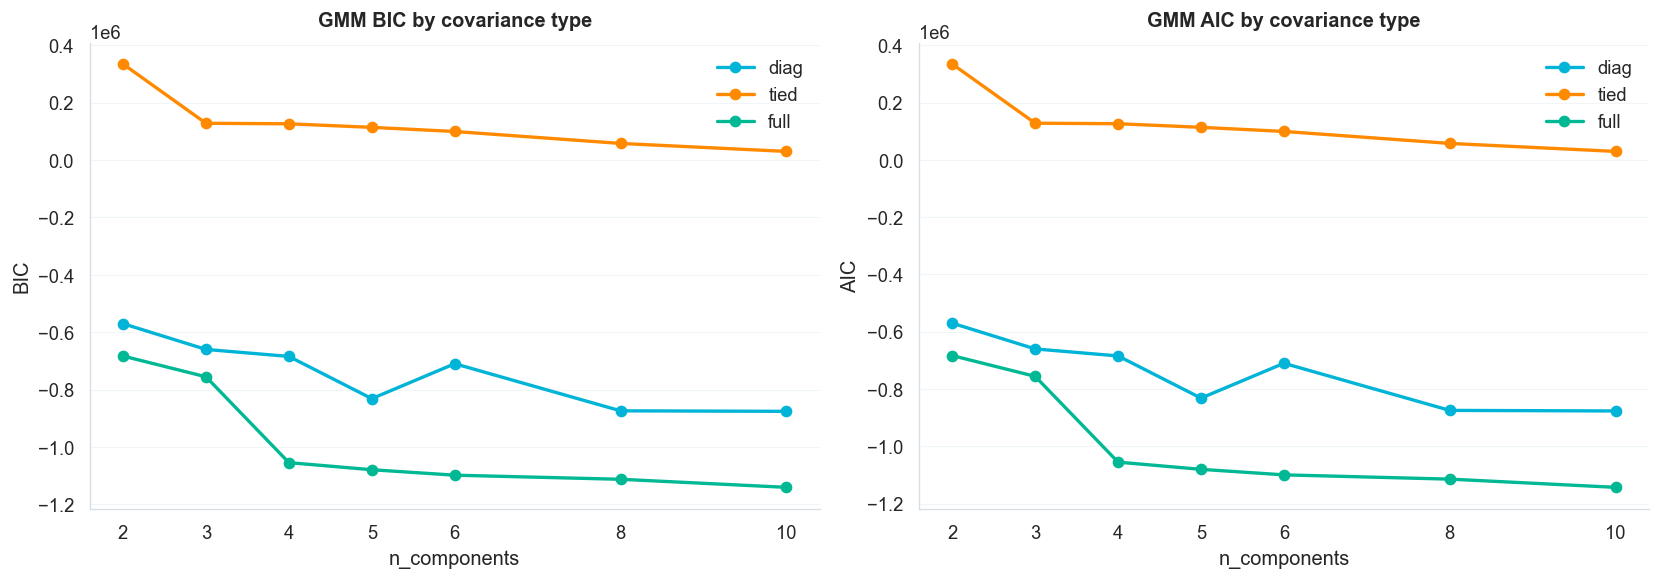

Best model per covariance type (lowest BIC):


,covariance_type,n_components,BIC,AIC
6,diag,10,-8.755533e+05,-8.768036e+05
20,full,10,-1.140426e+06,-1.143438e+06
13,tied,10,3.021545e+04,2.931763e+04


In [15]:
N_COMPONENTS = [2, 3, 4, 5, 6, 8, 10]
COV_TYPES = ["diag", "tied", "full"]

gmm_results = []
for cov in COV_TYPES:
    for n in N_COMPONENTS:
        gmm = GaussianMixture(
            n_components=n, covariance_type=cov,
            random_state=RANDOM_STATE, max_iter=200
        )
        gmm.fit(X_cont)
        gmm_results.append({
            "covariance_type": cov,
            "n_components": n,
            "BIC": gmm.bic(X_cont),
            "AIC": gmm.aic(X_cont)
        })

results_df = pd.DataFrame(gmm_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for cov in COV_TYPES:
    subset = results_df[results_df["covariance_type"] == cov]
    ax1.plot(subset["n_components"], subset["BIC"], marker="o", linewidth=2, label=cov)
    ax2.plot(subset["n_components"], subset["AIC"], marker="o", linewidth=2, label=cov)

ax1.set_title("GMM BIC by covariance type")
ax1.set_xlabel("n_components")
ax1.set_ylabel("BIC")
ax1.set_xticks(N_COMPONENTS)
ax1.legend()
polish_axes(ax1)

ax2.set_title("GMM AIC by covariance type")
ax2.set_xlabel("n_components")
ax2.set_ylabel("AIC")
ax2.set_xticks(N_COMPONENTS)
ax2.legend()
polish_axes(ax2)

plt.tight_layout()
plt.show()

print("Best model per covariance type (lowest BIC):")
display(results_df.loc[results_df.groupby("covariance_type")["BIC"].idxmin()])

The `tied` covariance type performs dramatically worse than the others (positive BIC and AIC values), indicating that a shared covariance matrix across all components is too restrictive for this data. The `full` covariance type consistently outperforms `diag`, suggesting that the components have genuinely different shapes and orientations rather than just different scales.

Both `full` and `diag` improve continuously with n_components with no sharp elbow. The `full` curve flattens noticeably after n=6, offering diminishing returns beyond that point. The selected configuration is `full` covariance with n=6, as the best balance between model fit and interpretability.

### 4.2 Component profiling

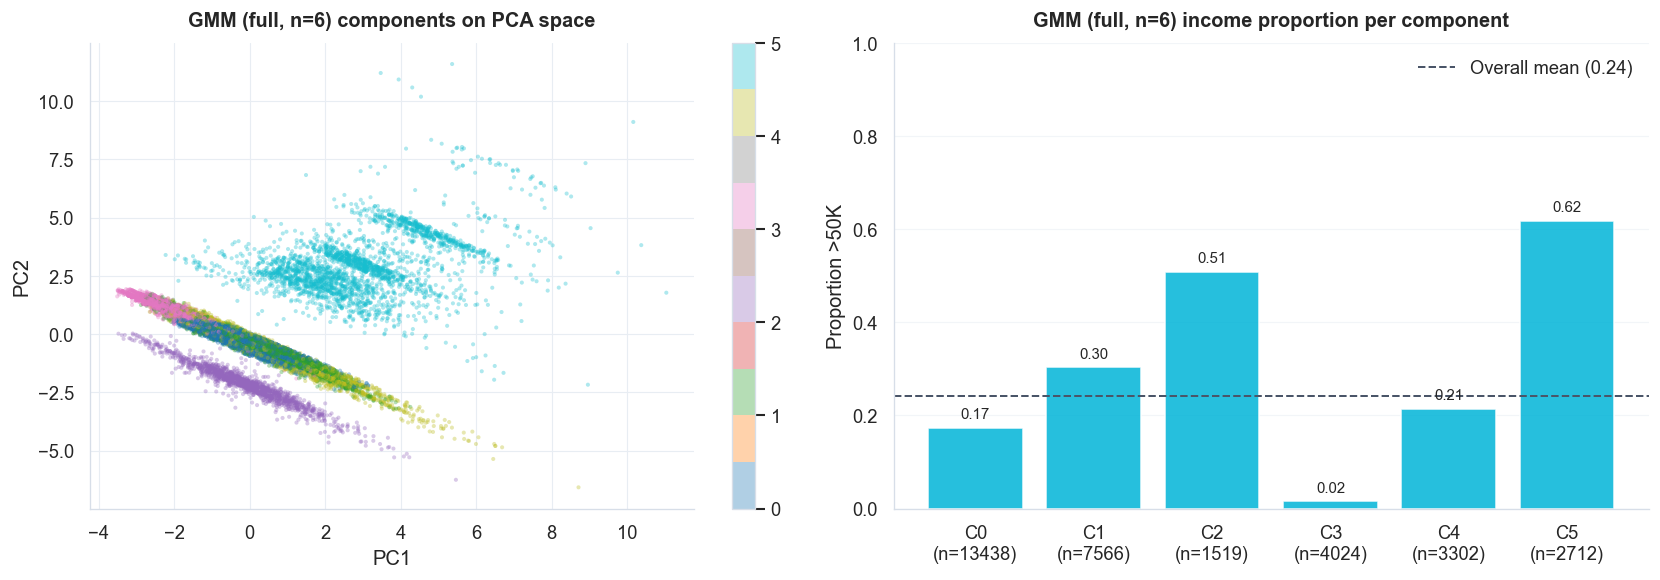

,size,income_prop,num__age,num__education_num,num__hours_per_week,num__capital_gain_log,num__capital_loss_log,num__net_capital,num__age_x_hours
Component 0,13438.0,0.173,-0.034,-0.117,-0.034,-0.301,-0.223,-0.205,-0.062
Component 1,7566.0,0.303,-0.097,0.223,0.660,-0.301,-0.223,-0.205,0.321
Component 2,1519.0,0.509,0.232,0.345,0.230,-0.301,4.486,-0.889,0.331
Component 3,4024.0,0.016,-1.222,-0.225,-1.025,-0.301,-0.223,-0.205,-1.291
Component 4,3302.0,0.214,1.451,-0.233,-0.422,-0.301,-0.223,-0.205,0.611
Component 5,2712.0,0.618,0.403,0.382,0.251,3.293,-0.223,2.613,0.450
Global mean,32561.0,0.241,0.004,0.000,0.001,-0.002,-0.003,-0.002,0.004


In [16]:
gmm_final = GaussianMixture(
    n_components=6, covariance_type="full",
    random_state=RANDOM_STATE, max_iter=200
)
gmm_final.fit(X_cont)
gmm_labels = gmm_final.predict(X_cont)
gmm_probs = gmm_final.predict_proba(X_cont)

gmm_df = X[CONTINUOUS_COLS].copy()
gmm_df["cluster"] = gmm_labels
gmm_df["income"] = y.values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

scatter = ax1.scatter(
    X_cont_pca[:, 0], X_cont_pca[:, 1],
    c=gmm_labels, cmap="tab10", alpha=0.35, s=6, edgecolors="none"
)
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_title("GMM (full, n=6) components on PCA space")
plt.colorbar(scatter, ax=ax1)

income_prop = gmm_df.groupby("cluster")["income"].mean()
cluster_size = gmm_df.groupby("cluster")["income"].count()

bars = ax2.bar(
    [f"C{c}\n(n={cluster_size[c]})" for c in income_prop.index],
    income_prop.values,
    color=PLOT_COLORS["neutral"], alpha=0.85
)
ax2.axhline(y.mean(), color=PLOT_COLORS["reference"], linestyle="--", linewidth=1.2,
            label=f"Overall mean ({y.mean():.2f})")
ax2.set_ylabel("Proportion >50K")
ax2.set_title("GMM (full, n=6) income proportion per component")
ax2.set_ylim(0, 1)
ax2.legend()
polish_axes(ax2)

for bar, val in zip(bars, income_prop.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

cluster_means = gmm_df.groupby("cluster")[CONTINUOUS_COLS].mean().round(3)
global_means = gmm_df[CONTINUOUS_COLS].mean().round(3)
profile_table = cluster_means.copy()
profile_table.loc["Global"] = global_means
profile_table.index = [f"Component {i}" for i in range(6)] + ["Global mean"]

summary = gmm_df.groupby("cluster").agg(
    size=("income", "count"),
    income_prop=("income", "mean")
).round(3)
summary.index = [f"Component {i}" for i in range(6)]
summary.loc["Global mean"] = [len(gmm_df), y.mean().round(3)]

final_table = pd.concat([summary, profile_table], axis=1)
display(final_table)

GMM with full covariance and n=6 recovers a more granular structure than K-Means k=4 while confirming its core findings. The capital activity components are reproduced almost identically. Component 5 (62% >50K) corresponds to the capital gains group and Component 2 (51% >50K) to the capital losses group, with nearly identical numeric profiles to the K-Means equivalents.

The main added value of GMM is the finer decomposition of the low-to-moderate income population. K-Means Cluster 3 is split into two distinct groups. Component 3 (2% >50K) captures extremely young part-time workers with very few hours, while Component 0 (17% >50K) represents the baseline low-income full-time worker close to the global mean on all features. Similarly, the older working group is split into Component 1 (30% >50K), defined by long working hours and moderate education, and Component 4 (21% >50K), the oldest subgroup with low capital activity corresponding to near-retirement individuals.

GMM confirms that capital activity is the strongest differentiator of high income while providing a more nuanced view of the low-to-moderate income population by separating age and hours-worked effects that K-Means merged into a single cluster.

In [17]:
gmm_profile_df = X.copy()
gmm_profile_df["cluster"] = gmm_labels
gmm_profile_df["income"] = y.values

bin_cols = [c for c in X.columns if c.startswith("bin__")]
bin_profile = gmm_profile_df.groupby("cluster")[bin_cols].mean().round(3)
bin_profile.loc["Global"] = gmm_profile_df[bin_cols].mean().round(3)
bin_profile.index = [f"Component {i}" for i in range(6)] + ["Global"]

print("Binary features proportion per component:")
display(bin_profile)

cat_groups = {
    "workclass": [c for c in X.columns if c.startswith("cat__workclass")],
    "education": [c for c in X.columns if c.startswith("cat__education_") and "num" not in c],
    "marital_status": [c for c in X.columns if c.startswith("cat__marital")],
    "occupation": [c for c in X.columns if c.startswith("cat__occupation")],
    "relationship": [c for c in X.columns if c.startswith("cat__relationship")],
    "race": [c for c in X.columns if c.startswith("cat__race")],
}

for var_name, cols in cat_groups.items():
    cluster_props = gmm_profile_df.groupby("cluster")[cols].mean().round(3)
    cluster_props.columns = [c.split("__")[-1] for c in cols]
    cluster_props.loc["Global"] = gmm_profile_df[cols].mean().round(3).values
    cluster_props.index = [f"Component {i}" for i in range(6)] + ["Global"]
    top_cols = cluster_props.iloc[:6].max().nlargest(3).index
    print(f"\n{var_name} proportion per component (top 3 categories):")
    display(cluster_props[top_cols])

Binary features proportion per component:


,bin__sex,bin__capital_gain_is_99999,bin__has_capital_activity,bin__is_higher_education,bin__is_US
Component 0,0.665,0.000,0.00,0.197,0.896
Component 1,0.732,0.000,0.00,0.331,0.923
Component 2,0.757,0.000,1.00,0.398,0.930
Component 3,0.503,0.000,0.00,0.118,0.924
Component 4,0.625,0.000,0.00,0.214,0.921
Component 5,0.770,0.059,1.00,0.417,0.929
Global,0.669,0.005,0.13,0.248,0.912



workclass proportion per component (top 3 categories):


,workclass_Private,workclass_Self-emp-not-inc,workclass_Unknown
Component 0,0.739,0.042,0.046
Component 1,0.685,0.114,0.025
Component 2,0.646,0.100,0.038
Component 3,0.778,0.026,0.106
Component 4,0.526,0.181,0.125
Component 5,0.639,0.096,0.045
Global,0.697,0.078,0.056



education proportion per component (top 3 categories):


...

,occupation_Other-service,occupation_Prof-specialty,occupation_Exec-managerial
Component 0,0.091,0.104,0.103
Component 1,0.074,0.160,0.171
Component 2,0.045,0.194,0.194
Component 3,0.227,0.074,0.036
Component 4,0.131,0.119,0.120
Component 5,0.038,0.205,0.204
Global,0.101,0.127,0.125



relationship proportion per component (top 3 categories):


,relationship_Husband,relationship_Own-child,relationship_Not-in-family
Component 0,0.391,0.149,0.258
Component 1,0.484,0.061,0.272
Component 2,0.564,0.076,0.220
Component 3,0.059,0.565,0.232
Component 4,0.481,0.019,0.292
Component 5,0.589,0.052,0.201
Global,0.405,0.156,0.255



race proportion per component (top 3 categories):


,race_White,race_Black,race_Asian-Pac-Islander
Component 0,0.821,0.121,0.037
Component 1,0.886,0.072,0.027
Component 2,0.886,0.068,0.036
Component 3,0.851,0.095,0.034
Component 4,0.879,0.086,0.022
Component 5,0.888,0.067,0.031
Global,0.854,0.096,0.032


The categorical profiling confirms and enriches the numeric interpretation of each component.

Component 3 (2% >50K) is a young single pre-career group. Almost entirely never-married (85%), predominantly in the own-child relationship role (57%), with the highest share of service occupations (23%), the lowest education, and the least male composition (50%).

Component 0 (17% >50K) has the most generic profile, close to global proportions on most variables. Mostly private sector (74%) and HS-grad educated (37%) with a mix of married and never-married individuals and no distinguishing categorical signal, making it the heterogeneous baseline group.

Component 4 (21% >50K) is the oldest group numerically, with the highest share of self-employed (18%) and unknown workclass (13%), mostly married (55%) and low education (35% HS-grad). The elevated self-employment rate is consistent with older individuals who have transitioned out of traditional employment.

Component 1 (30% >50K) works the most hours, is mostly private sector (69%), has a higher share of Bachelor-educated individuals (22%) and exec or professional occupations than Components 0 and 3, and is mostly composed of married husbands (48%).

Component 2 (51% >50K) shows 100% capital activity with a focus on losses, is mostly married (63%), and has professional or exec occupations (19% each). This matches the K-Means Cluster 2 profile almost exactly.

Component 5 (62% >50K) shows 100% capital activity, with 6% recording the maximum capital gain. It is the most educated component (42% higher education), has the highest share of exec or professional occupations (20% each), and is predominantly composed of married husbands (59%). This is the high-income investor and professional class.

As with K-Means, race does not meaningfully differentiate components, remaining close to global proportions across all groups.

## 5. K-Prototypes clustering

K-Means and GMM were applied exclusively to the continuous features due to the limitations of distance-based methods on one-hot encoded data. As a complementary analysis, K-Prototypes is applied as an extension of K-Means designed for mixed data that handles numerical and categorical variables jointly without requiring one-hot encoding. This allows an assessment of whether incorporating categorical information (occupation, marital status, relationship, education, and others) changes the cluster structure found on continuous features alone.

The categorical columns are reconstructed from their one-hot encoded versions for this section only and are not used in any other part of the pipeline.

### 5.1 Data preparation

In [18]:
!pip install kmodes -q

from kmodes.kprototypes import KPrototypes

cat_reconstruct = {
    "workclass": [c for c in X.columns if c.startswith("cat__workclass")],
    "education": [c for c in X.columns if c.startswith("cat__education_") and "num" not in c],
    "marital_status": [c for c in X.columns if c.startswith("cat__marital")],
    "occupation": [c for c in X.columns if c.startswith("cat__occupation")],
    "relationship": [c for c in X.columns if c.startswith("cat__relationship")],
    "race": [c for c in X.columns if c.startswith("cat__race")],
    "capital_direction": [c for c in X.columns if c.startswith("cat__capital_direction")],
}

df_mixed = X[CONTINUOUS_COLS].copy()

for var_name, cols in cat_reconstruct.items():
    df_mixed[var_name] = X[cols].idxmax(axis=1).str.split("__").str[-1]

bin_cols = [c for c in X.columns if c.startswith("bin__")]
for col in bin_cols:
    df_mixed[col] = X[col].astype(str)

cat_col_names = list(cat_reconstruct.keys()) + bin_cols
num_col_names = CONTINUOUS_COLS

cols_ordered = num_col_names + cat_col_names
df_kproto = df_mixed[cols_ordered].copy()
cat_indices = list(range(len(num_col_names), len(cols_ordered)))

print(f"Numeric columns: {len(num_col_names)}")
print(f"Categorical columns: {len(cat_col_names)}")
print(f"Total: {df_kproto.shape[1]}")
display(df_kproto.head(3))


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Numeric columns: 7
Categorical columns: 12
Total: 19


,num__age,num__education_num,num__hours_per_week,num__capital_gain_log,num__capital_loss_log,num__net_capital,num__age_x_hours,workclass,education,marital_status,occupation,relationship,race,capital_direction,bin__sex,bin__capital_gain_is_99999,bin__has_capital_activity,bin__is_higher_education,bin__is_US
0,3.776660,-0.419226,-0.03412,-0.300842,5.031931,-1.797389,2.754749,workclass_Unknown,education_HS-grad,marital_status_Widowed,occupation_Unknown,relationship_Not-in-family,race_White,capital_direction_loss,0.0,0.0,1.0,0.0,1.0
1,3.189651,-0.419226,-1.81908,-0.300842,5.031931,-1.797389,-0.125426,workclass_Private,education_HS-grad,marital_status_Widowed,occupation_Exec-managerial,relationship_Not-in-family,race_White,capital_direction_loss,0.0,0.0,1.0,0.0,1.0
2,2.015634,-0.031235,-0.03412,-0.300842,5.031931,-1.797389,1.452975,workclass_Unknown,education_Some-college,marital_status_Widowed,occupation_Unknown,relationship_Unmarried,race_Black,capital_direction_loss,0.0,0.0,1.0,0.0,1.0


### 5.2 Cluster count selection

Fitting k=2...
  cost=245982
Fitting k=3...
  cost=194320
Fitting k=4...
  cost=162036
Fitting k=5...
  cost=145258
Fitting k=6...
  cost=134613


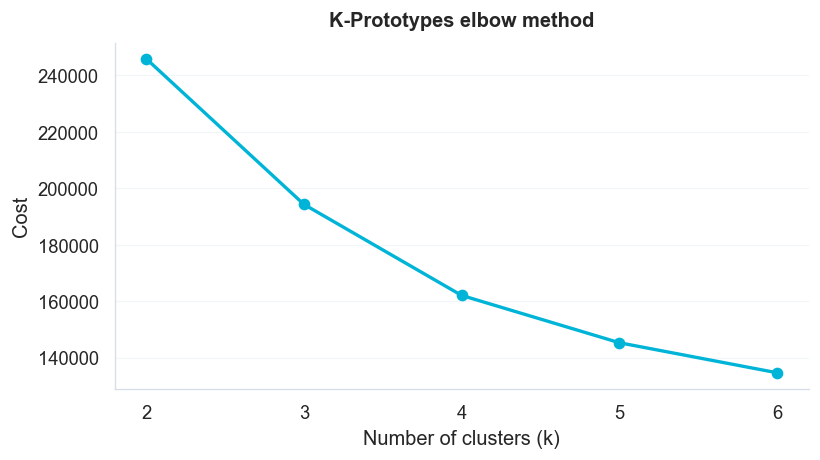

In [19]:
K_VALUES_KP = [2, 3, 4, 5, 6]

costs = []
X_kproto = df_kproto.values

for k in K_VALUES_KP:
    print(f"Fitting k={k}...")
    kp = KPrototypes(n_clusters=k, random_state=RANDOM_STATE, n_init=5)
    kp.fit(X_kproto, categorical=cat_indices)
    costs.append(kp.cost_)
    print(f"  cost={kp.cost_:.0f}")

plt.figure(figsize=(7, 4))
plt.plot(K_VALUES_KP, costs, marker="o", color=PLOT_COLORS["neutral"], linewidth=2)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Cost")
plt.title("K-Prototypes elbow method")
plt.xticks(K_VALUES_KP)
polish_axes(plt.gca())
plt.tight_layout()
plt.show()

The elbow curve shows a gradual decrease with no sharp bend, consistent with the pattern observed in K-Means. The most visible inflection occurs around k=4, which is adopted for consistency with the previous analyses and to allow direct comparison of the resulting groups.

### 5.3 Cluster profiling

In [20]:
kp_final = KPrototypes(n_clusters=4, random_state=RANDOM_STATE, n_init=5)
kp_labels = kp_final.fit_predict(X_kproto, categorical=cat_indices)

kproto_df = df_kproto.copy()
kproto_df["cluster"] = kp_labels
kproto_df["income"] = y.values

summary = kproto_df.groupby("cluster").agg(
    size=("income", "count"),
    income_prop=("income", "mean")
).round(3)
summary.index = [f"Cluster {i}" for i in range(4)]
summary.loc["Global"] = [len(kproto_df), y.mean().round(3)]
print("Cluster summary:")
display(summary)

cluster_means = kproto_df.groupby("cluster")[num_col_names].mean().round(3)
cluster_means.loc["Global"] = kproto_df[num_col_names].mean().round(3)
cluster_means.index = [f"Cluster {i}" for i in range(4)] + ["Global"]
print("\nNumeric means per cluster:")
display(cluster_means)

cat_original = list(cat_reconstruct.keys())
cluster_modes = kproto_df.groupby("cluster")[cat_original].agg(
    lambda x: x.value_counts().index[0]
)
cluster_modes.index = [f"Cluster {i}" for i in range(4)]
print("\nMost frequent category per cluster:")
display(cluster_modes)

Cluster summary:


,size,income_prop
Cluster 0,14563.0,0.315
Cluster 1,2634.0,0.637
Cluster 2,1519.0,0.509
Cluster 3,13845.0,0.058
Global,32561.0,0.241



Numeric means per cluster:


,num__age,num__education_num,num__hours_per_week,num__capital_gain_log,num__capital_loss_log,num__net_capital,num__age_x_hours
Cluster 0,0.622,0.075,0.375,-0.300,-0.223,-0.204,0.672
Cluster 1,0.440,0.409,0.293,3.318,-0.223,2.686,0.500
Cluster 2,0.232,0.345,0.230,-0.301,4.486,-0.889,0.331
Cluster 3,-0.755,-0.194,-0.473,-0.287,-0.223,-0.203,-0.828
Global,0.004,0.000,0.001,-0.002,-0.003,-0.002,0.004



Most frequent category per cluster:


,workclass,education,marital_status,occupation,relationship,race,capital_direction
Cluster 0,workclass_Private,education_HS-grad,marital_status_Married-civ-spouse,occupation_Exec-managerial,relationship_Husband,race_White,capital_direction_none
Cluster 1,workclass_Private,education_HS-grad,marital_status_Married-civ-spouse,occupation_Prof-specialty,relationship_Husband,race_White,capital_direction_gain
Cluster 2,workclass_Private,education_HS-grad,marital_status_Married-civ-spouse,occupation_Exec-managerial,relationship_Husband,race_White,capital_direction_loss
Cluster 3,workclass_Private,education_HS-grad,marital_status_Never-married,occupation_Other-service,relationship_Own-child,race_White,capital_direction_none


The K-Prototypes clustering with k=4 recovers a structure remarkably consistent with K-Means despite incorporating categorical variables directly. The four clusters map almost exactly onto the K-Means groups.

Cluster 3 (6% >50K, n=13,845) is the youngest, least active group with the fewest hours. Mode categories confirm never-married, own-child relationship, and service occupation, matching K-Means Cluster 3.

Cluster 0 (32% >50K, n=14,563) is the older working group with more hours and no capital activity. Mode confirms married, husband, private sector, HS-grad, and exec-managerial occupation, matching K-Means Cluster 0.

Cluster 2 (51% >50K, n=1,519) is identical in both size and numeric profile to K-Means Cluster 2, with the mode confirming married, husband, private sector, and capital direction loss.

Cluster 1 (64% >50K, n=2,634) is the capital-wealthy professional group with high capital gains and net capital. Mode confirms married husband, Prof-specialty occupation, and capital direction gain, matching K-Means Cluster 1.

The strong consistency between K-Means and K-Prototypes is the key finding of this section. Adding categorical variables directly does not meaningfully change the cluster structure. This suggests that the continuous features, particularly capital activity and age, are the primary drivers of natural groupings in this dataset and that categorical variables are largely aligned with those same groupings rather than introducing independent structure. This retrospectively validates the decision to run K-Means and GMM on continuous features only.

## 6. Summary

The three clustering methods (K-Means, GMM, and K-Prototypes) and PCA converge on a consistent picture of the dataset's natural structure.

**PCA** showed that the continuous features carry largely independent information, requiring four components to explain 80% of variance. The first component, driven by age, work hours, and capital gains, shows a clear gradient with income despite being constructed without the label. The directions of maximum variance do not always coincide with the most discriminative directions, as illustrated by the PC3 vs PC4 plot showing clearer income separation despite lower explained variance. This reflects a key limitation of PCA as an unsupervised method.

**K-Means (k=4)** identified four socioeconomically meaningful groups with a clear income gradient. Young single low-income workers (8% >50K), older working-class married men (31%), financially active individuals with capital losses (51%), and capital-wealthy professionals (64%). Capital activity emerged as the strongest differentiator of high income, more so than age or education in isolation.

**GMM (full, n=6)** confirmed the K-Means structure while providing finer granularity within the low-to-moderate income population, separating it into part-time young workers, baseline full-time workers, hardworking moderate-income employees, and near-retirement individuals. The two capital activity components were recovered with nearly identical numeric profiles to their K-Means counterparts.

**K-Prototypes** incorporated categorical variables directly and produced a cluster structure nearly identical to K-Means, confirming that the continuous features are the primary drivers of natural groupings in this dataset. This retrospectively validates the choice to apply K-Means and GMM on continuous features only.

Overall, income in this dataset is primarily stratified along two axes. The first is capital activity (both gains and losses) and the second is the combination of age and work hours. Categorical variables such as marital status, occupation, and relationship are strongly aligned with these axes but do not introduce independent cluster structure. These findings provide a useful foundation for the supervised modeling phases that follow.